Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce
License(s): CC-BY-NC-SA-4.0
100% 42.6M/42.6M [00:00<00:00, 149MB/s]

Archive:  brazilian-ecommerce.zip
  inflating: olist_customers_dataset.csv  
  inflating: olist_geolocation_dataset.csv  
  inflating: olist_order_items_dataset.csv  
  inflating: olist_order_payments_dataset.csv  
  inflating: olist_order_reviews_dataset.csv  
  inflating: olist_orders_dataset.csv  
  inflating: olist_products_dataset.csv  
  inflating: olist_sellers_dataset.csv  
  inflating: product_category_name_translation.csv  
Shape after merge: (117601, 30)

Target Distribution:
target
0    117028
1       573
Name: count, dtype: int64

Class Distribution:
target
0    0.995267
1    0.004733
Name: proportion, dtype: float64

CV ROC-AUC: [0.48881699 0.44936628 0.46187696 0.49220071 0.48651836]
Mean ROC-AUC: 0.47575585890587446

Default Threshold (0.5) Results
Accuracy: 0.9134471155795192

Classification Repo

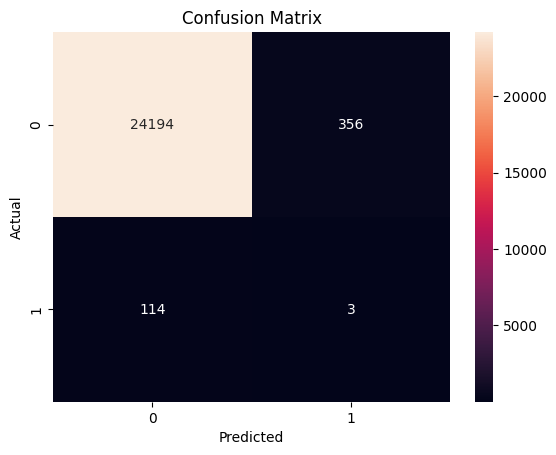

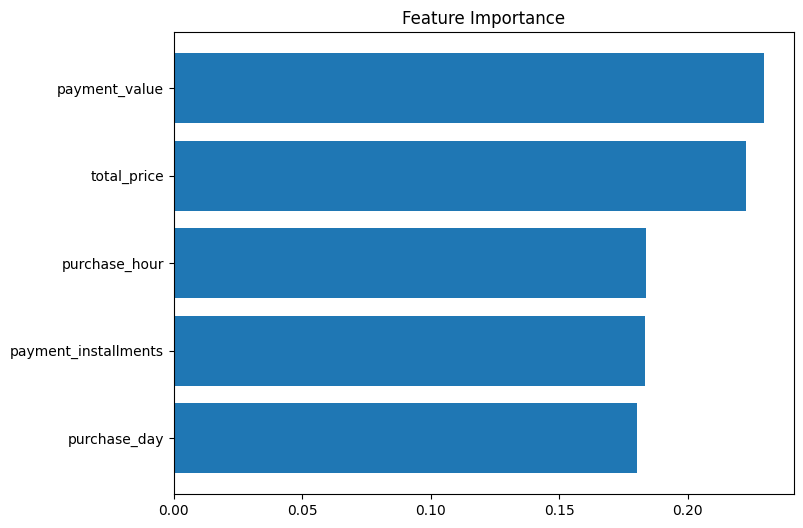


Top Feature: Feature       payment_value
Importance         0.229786
Name: 3, dtype: object

Random Forest Accuracy: 0.9952162808610694


In [1]:
# 1. INSTALL & DOWNLOAD DATASET
!pip install kaggle xgboost

from google.colab import files
files.upload()  # Upload kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d olistbr/brazilian-ecommerce
!unzip -o brazilian-ecommerce.zip


# 2. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

from xgboost import XGBClassifier


# 3. LOAD DATA
orders = pd.read_csv("olist_orders_dataset.csv")
customers = pd.read_csv("olist_customers_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")


# 4. MERGE DATA
df = orders.merge(customers, on="customer_id")
df = df.merge(order_items, on="order_id")
df = df.merge(payments, on="order_id")
df = df.merge(products, on="product_id")

print("Shape after merge:", df.shape)


# 5. CREATE TARGET (RETURN / CANCEL)
# 1 = risky order (cancelled/unavailable)
df['target'] = df['order_status'].apply(
    lambda x: 1 if x in ['canceled', 'unavailable'] else 0
)

print("\nTarget Distribution:")
print(df['target'].value_counts())


# 6. FEATURE ENGINEERING (NO DATA LEAKAGE)

# Convert datetime
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

# Extract safe time features (available at purchase time)
df['purchase_hour'] = df['order_purchase_timestamp'].dt.hour
df['purchase_day'] = df['order_purchase_timestamp'].dt.dayofweek

# Price-based features
df['total_price'] = df['price'] + df['freight_value']

# Remove duplicates (important)
df = df.drop_duplicates(subset=['order_id'])


# 7. SELECT FEATURES (NO LEAKAGE FEATURES)
features = [
    'purchase_hour',
    'purchase_day',
    'total_price',
    'payment_value',
    'payment_installments'
]

X = df[features]
y = df['target']

print("\nClass Distribution:")
print(y.value_counts(normalize=True))


# 8. TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)


# 9. HANDLE CLASS IMBALANCE
# Give higher weight to rare "return" class
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()


# 10. TRAIN MODEL (XGBOOST)
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train, y_train)


# 11. CROSS VALIDATION
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc')

print("\nCV ROC-AUC:", cv_scores)
print("Mean ROC-AUC:", cv_scores.mean())


# 12. PREDICTIONS
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]


# 13. DEFAULT EVALUATION
print("\nDefault Threshold (0.5) Results")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


# 14. THRESHOLD TUNING
# Custom threshold to balance precision vs recall
threshold = 0.7

y_pred_custom = (y_prob > threshold).astype(int)

print("\nCustom Threshold:", threshold)
print("Accuracy:", accuracy_score(y_test, y_pred_custom))
print("\nClassification Report:\n", classification_report(y_test, y_pred_custom))


# 15. CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred_custom)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# 16. FEATURE IMPORTANCE
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,6))
plt.barh(importance['Feature'], importance['Importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()

print("\nTop Feature:", importance.iloc[0])


# 17. (OPTIONAL) BASELINE COMPARISON MODEL
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("\nRandom Forest Accuracy:", accuracy_score(y_test, rf_pred))